In [3]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [4]:
import yfinance as yf
import pandas as pd

data = yf.download("SPY", start="2015-01-01", end="2026-08-01", progress=False)

# Flatten the MultiIndex columns down to simple names
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.shape)
print(data.head())

(2911, 5)
Price            Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687851  170.885580  168.655335  170.472573  121465900
2015-01-05  166.623291  168.812220  166.317670  168.647020  169632600
2015-01-06  165.053879  167.449311  164.260901  166.928919  209151400
2015-01-07  167.110703  167.449371  165.929510  166.375551  125346700
2015-01-08  170.076111  170.290882  168.498435  168.514946  147217800


In [5]:
data.to_csv(ROOT / "data" / "raw" / "spy_raw.csv")
print(f"Saved {len(data)} rows to data/raw/spy_raw.csv")

Saved 2911 rows to data/raw/spy_raw.csv


Data Source & Validation
Source: Yahoo Finance, via the yfinance Python library (API pull, no manual download or key required)
Ticker: SPY
Date range: 2015-01-01 to 2026-08-01
Rows: 2,911
Validation: no missing values found (see check below); date range and row count consistent with expected trading days over this period

In [6]:
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [7]:
from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.append(str(ROOT / "src"))
from utils import save_raw_data, load_raw_data

# Save using the new env-driven function
save_raw_data(data, "spy_raw.csv")

# Reload to confirm it round-trips correctly
reloaded = load_raw_data("spy_raw.csv")
print(reloaded.head())

Saved 2911 rows to data/raw/spy_raw.csv
Loaded 2911 rows from data/raw/spy_raw.csv
                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687851  170.885580  168.655335  170.472573  121465900
2015-01-05  166.623291  168.812220  166.317670  168.647020  169632600
2015-01-06  165.053879  167.449311  164.260901  166.928919  209151400
2015-01-07  167.110703  167.449371  165.929510  166.375551  125346700
2015-01-08  170.076111  170.290882  168.498435  168.514946  147217800


In [8]:
sys.path.append(str(ROOT / "src"))
from cleaning import preprocess_pipeline

raw = load_raw_data("spy_raw.csv")
processed = preprocess_pipeline(raw)

processed.to_csv(ROOT / "data" / "processed" / "spy_processed.csv")
print(f"Saved {len(processed)} processed rows")
print(processed.head())

Loaded 2911 rows from data/raw/spy_raw.csv
Removed 0 duplicate rows
Filled 0 missing values via forward-fill
Saved 2911 processed rows
                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687851  170.885580  168.655335  170.472573  121465900
2015-01-05  166.623291  168.812220  166.317670  168.647020  169632600
2015-01-06  165.053879  167.449311  164.260901  166.928919  209151400
2015-01-07  167.110703  167.449371  165.929510  166.375551  125346700
2015-01-08  170.076111  170.290882  168.498435  168.514946  147217800


Preprocessing assumptions: Missing values are forward-filled, assuming the last known price holds until new data arrives (standard for financial time series, avoids fabricating values). Duplicate dates are dropped, keeping the first occurrence. Data is sorted chronologically to support time-series modeling in later stages.

In [9]:
sys.path.append(str(ROOT / "src"))
from outliers import detect_outliers_zscore, remove_outliers

flagged = detect_outliers_zscore(processed)
print(flagged[flagged["is_outlier"]][["Close"]])

Flagged 39 outliers out of 2911 rows (1.34%)
                 Close
Date                  
2015-08-24  157.992966
2015-08-26  162.128296
2016-06-24  173.122513
2018-02-05  231.705231
2018-02-08  226.174423
2018-12-26  220.227615
2020-02-24  293.892059
2020-02-27  271.186127
2020-03-02  281.741516
2020-03-04  285.177856
2020-03-05  275.698120
2020-03-09  249.965988
2020-03-10  262.900391
2020-03-11  250.084427
2020-03-12  226.157104
2020-03-13  245.490356
2020-03-16  218.627930
2020-03-17  230.432083
2020-03-18  218.764664
2020-03-20  209.781998
2020-03-24  222.939178
2020-03-26  239.488907
2020-04-01  225.689865
2020-04-06  242.844650
2020-06-11  275.623108
2020-09-03  318.074554
2020-10-28  302.030029
2022-04-29  388.862946
2022-05-05  390.571289
2022-05-18  369.853973
2022-06-13  353.940765
2022-06-16  346.059753
2022-08-26  384.201141
2022-09-13  372.627045
2022-11-10  375.671173
2025-04-03  529.253723
2025-04-04  498.269714
2025-04-09  541.008423
2025-04-10  517.301941


In [10]:
sys.path.append(str(ROOT / "src"))
from eda import eda_summary
import matplotlib.pyplot as plt

summary_stats = eda_summary(processed)

mean_price: 354.620122
median_price: 317.637207
std_price: 158.715465
min_price: 154.161667
max_price: 757.618225
missing_values: 0
mean_daily_return: 0.000571
std_daily_return: 0.011097
skewness_returns: -0.307512


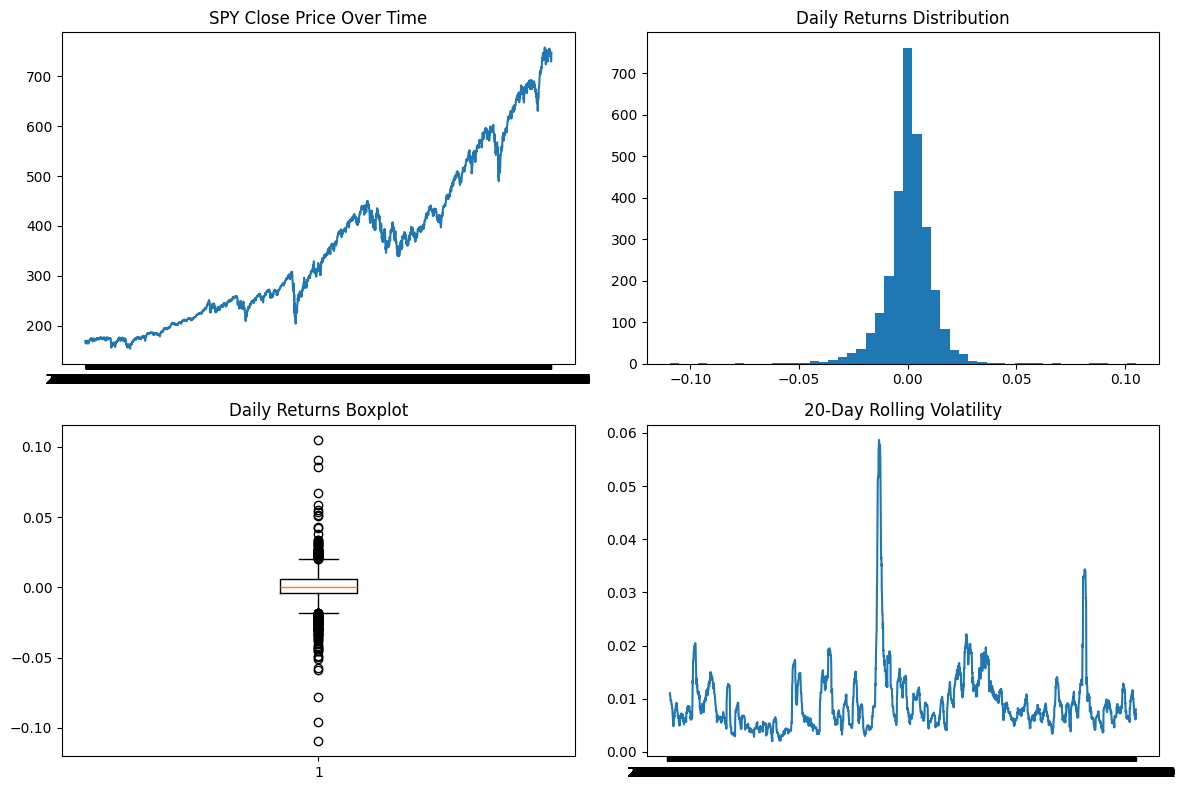

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Time series
axes[0, 0].plot(processed.index, processed["Close"])
axes[0, 0].set_title("SPY Close Price Over Time")

# Returns histogram
returns = processed["Close"].pct_change().dropna()
axes[0, 1].hist(returns, bins=50)
axes[0, 1].set_title("Daily Returns Distribution")

# Boxplot - shows outliers visually
axes[1, 0].boxplot(returns)
axes[1, 0].set_title("Daily Returns Boxplot")

# Rolling volatility (bonus insight, cheap to add)
rolling_vol = returns.rolling(20).std()
axes[1, 1].plot(processed.index[1:], rolling_vol)
axes[1, 1].set_title("20-Day Rolling Volatility")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "eda_summary.png")
plt.show()

In [12]:
sys.path.append(str(ROOT / "src"))
from features import build_features

featured = build_features(processed)
featured.to_csv(ROOT / "data" / "processed" / "spy_features.csv")
print(f"Built {len(featured)} rows with {featured.shape[1]} columns")
print(featured.columns.tolist())
print(featured.head())

Built 2891 rows with 12 columns
['Close', 'High', 'Low', 'Open', 'Volume', 'ma_5', 'ma_10', 'ma_20', 'momentum', 'volatility', 'rsi', 'target']
                 Close        High         Low        Open     Volume  \
Date                                                                    
2015-02-02  166.788483  166.879345  163.434873  165.243843  163107000   
2015-02-03  169.200485  169.208753  167.308921  167.680624  124212900   
2015-02-04  168.556229  169.646572  168.101919  168.440587  134306700   
2015-02-05  170.257797  170.406486  169.142687  169.217025   97953200   
2015-02-06  169.786972  171.182936  169.266580  170.621241  125672000   

                  ma_5       ma_10       ma_20  momentum  volatility  \
Date                                                                   
2015-02-02  166.233475  167.507187  167.190813  0.239471    0.011050   
2015-02-03  166.580389  167.736816  167.319673  2.296295    0.010766   
2015-02-04  167.227975  167.817763  167.494791  0.809464

In [13]:
sys.path.append(str(ROOT / "src"))
from model import run_walk_forward, FEATURE_COLS

logistic_results = run_walk_forward(featured, model_type="logistic")
rf_results = run_walk_forward(featured, model_type="random_forest")

print("Logistic Regression - walk-forward results:")
print(logistic_results)
print(f"\nMean accuracy: {logistic_results['accuracy'].mean():.4f}")

print("\nRandom Forest - walk-forward results:")
print(rf_results)
print(f"\nMean accuracy: {rf_results['accuracy'].mean():.4f}")

Logistic Regression - walk-forward results:
   accuracy  precision    recall  n_test  fold
0  0.528067   0.552279  0.774436     481     1
1  0.538462   0.597360  0.644128     481     2
2  0.525988   0.525988  1.000000     481     3
3  0.544699   0.544699  1.000000     481     4
4  0.563410   0.563410  1.000000     481     5

Mean accuracy: 0.5401

Random Forest - walk-forward results:
   accuracy  precision    recall  n_test  fold
0  0.490644   0.576642  0.296992     481     1
1  0.440748   0.611111  0.117438     481     2
2  0.480249   1.000000  0.011858     481     3
3  0.496881   0.548544  0.431298     481     4
4  0.455301   0.695652  0.059041     481     5

Mean accuracy: 0.4728


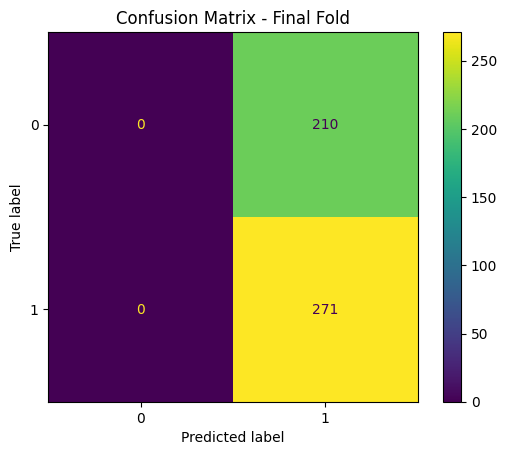

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from model import build_pipeline, walk_forward_split

# Refit on the last fold for a concrete diagnostic view
last_train, last_test = walk_forward_split(featured, n_splits=5)[-1]
pipeline = build_pipeline("logistic")
pipeline.fit(last_train[FEATURE_COLS], last_train["target"])
preds = pipeline.predict(last_test[FEATURE_COLS])

ConfusionMatrixDisplay.from_predictions(last_test["target"], preds)
plt.title("Confusion Matrix - Final Fold")
plt.savefig(ROOT / "reports" / "images" / "confusion_matrix.png")
plt.show()

In [15]:
sys.path.append(str(ROOT / "src"))
from evaluations import bootstrap_accuracy_ci, majority_baseline_ci, compare_scenarios

# Bootstrap CI on the final fold's actual predictions (from Stage 10's confusion matrix)
model_mean, model_lower, model_upper = bootstrap_accuracy_ci(last_test["target"], preds)
print(f"Model accuracy: {model_mean:.4f} [{model_lower:.4f}, {model_upper:.4f}]")

# Same CI, computed for the naive majority-class baseline
majority_class = last_train["target"].mode()[0]
base_mean, base_lower, base_upper = majority_baseline_ci(last_test["target"], majority_class)
print(f"Baseline accuracy: {base_mean:.4f} [{base_lower:.4f}, {base_upper:.4f}]")

Model accuracy: 0.5626 [0.5197, 0.6071]
Baseline accuracy: 0.5626 [0.5197, 0.6071]


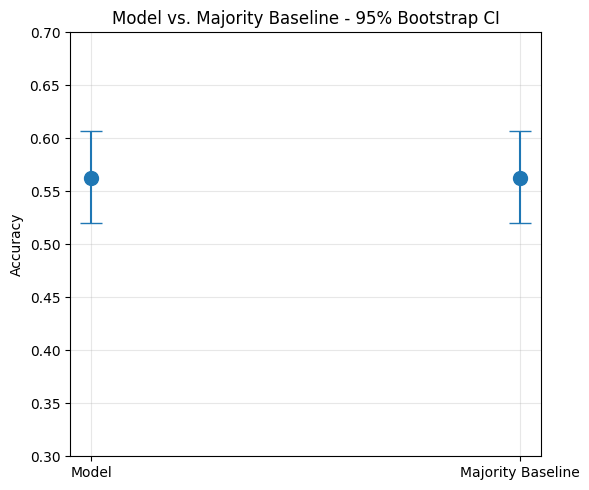

In [16]:
import matplotlib.pyplot as plt

labels = ["Model", "Majority Baseline"]
means = [model_mean, base_mean]
lowers = [model_mean - model_lower, base_mean - base_lower]
uppers = [model_upper - model_mean, base_upper - base_mean]

fig, ax = plt.subplots(figsize=(6, 5))
ax.errorbar(labels, means, yerr=[lowers, uppers], fmt='o', capsize=8, markersize=10)
ax.set_ylabel("Accuracy")
ax.set_title("Model vs. Majority Baseline - 95% Bootstrap CI")
ax.set_ylim(0.3, 0.7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "bootstrap_ci_comparison.png")
plt.show()

In [17]:
from model import build_pipeline, FEATURE_COLS

def quick_accuracy(df, cols, target_col):
    train, test = walk_forward_split(df, n_splits=5)[-1]
    pipe = build_pipeline("logistic")
    pipe.fit(train[cols], train[target_col])
    preds = pipe.predict(test[cols])
    return (preds == test[target_col].values).mean()

scenarios = {
    "full_feature_set": FEATURE_COLS,
    "momentum_only": ["momentum", "volatility"],
}

scenario_results = compare_scenarios(featured, quick_accuracy, scenarios)
print(scenario_results)

{'full_feature_set': np.float64(0.5634095634095634), 'momentum_only': np.float64(0.5634095634095634)}


In [18]:
print("Stakeholder report generated: reports/stakeholder_report.md")
print("Includes: confusion matrix, bootstrap CI comparison, scenario sensitivity, assumptions & risks")

Stakeholder report generated: reports/stakeholder_report.md
Includes: confusion matrix, bootstrap CI comparison, scenario sensitivity, assumptions & risks


In [19]:
from model import save_model, load_model

save_model(pipeline, str(ROOT / "model" / "model.pkl"))

Model saved to /Users/a1/Desktop/bootcamp_kashish_dhoka/project/model/model.pkl


In [21]:
# Verify refactor didn't change anything
from model import load_model, predict_direction

loaded_pipeline = load_model(str(ROOT / "model" / "model.pkl"))
sample_row = last_test.iloc[0]
refactored_pred = predict_direction(loaded_pipeline, sample_row[FEATURE_COLS].to_dict())
original_pred = preds[0]

print(f"Original prediction: {original_pred}, Refactored prediction: {refactored_pred}")
assert original_pred == refactored_pred, "Refactor changed behavior!"
print("Refactor verified - matches original.")

ImportError: cannot import name 'predict_direction' from 'model' (/Users/a1/Desktop/bootcamp_kashish_dhoka/project/src/model.py)